# 🛡️ Insurance Claim Fraud Detection + Severity Prediction
### A two-stage ML walkthrough (Jupyter · Python · scikit-learn · XGBoost · SHAP)

This notebook builds and explains the full pipeline interactively:

1. **Stage 1 — Fraud classification**: is the claim fraudulent?
2. **Stage 2 — Severity prediction**: for *genuine* claims only, how much to reserve?

The two models are **chained**: flagged claims stop at Stage 1 (`NEEDS REVIEW`); genuine claims flow to Stage 2 for a severity estimate.

> This notebook reuses the project's shared preprocessing pipeline so experiments match production. The full modular code lives in `src/`, served via `flask_app.py` (Flask).

## 0 · Setup
Import the scientific stack and the project's helpers.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
# make the project root importable whether this notebook is launched from
# the repo root or from notebooks/ (so `import src...` always works)
import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, accuracy_score, precision_recall_curve,
    mean_squared_error, mean_absolute_error, r2_score)
from xgboost import XGBClassifier, XGBRegressor
import shap

# project helpers (single source of truth for transforms)
from src.config import load_config
from scripts.generate_synthetic_data import generate
from src.feature_engineering import build_preprocessor, get_feature_names

cfg = load_config(); RANDOM_STATE = cfg.get('project.random_state')
sns.set_theme(style='whitegrid')
print('setup OK')

setup OK


## 1 · Get the data
We generate a synthetic dataset that matches the Kaggle *Auto Insurance Claims* schema exactly (40 columns, incl. `fraud_reported` and `total_claim_amount`). To use the **real** dataset instead, download it from Kaggle, save it as `data/raw/insurance_claims.csv`, and load that file here.

In [2]:
df = generate(n_rows=2000, seed=RANDOM_STATE)
print('shape:', df.shape)
df[['age','incident_severity','police_report_available','total_claim_amount',
    'injury_claim','property_claim','vehicle_claim','fraud_reported']].head()

shape: (2000, 40)


,age,incident_severity,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,fraud_reported
0,44,Minor Damage,?,39930,4010,7690,28230,N
1,50,Major Damage,YES,55170,8790,7690,38690,N
2,55,Minor Damage,NO,27720,5740,370,21610,N
3,47,Major Damage,YES,80560,9760,5410,65390,N
4,56,Major Damage,YES,65020,11610,5800,47610,Y


**Note the arithmetic identity** — the three claim components sum to the target. This is why they are *leakage* for the severity model (more in Step 5).

In [3]:
ok = (df.injury_claim + df.property_claim + df.vehicle_claim == df.total_claim_amount).all()
print('total_claim_amount == injury + property + vehicle :', bool(ok))

total_claim_amount == injury + property + vehicle : True


## 2 · EDA — why accuracy is the WRONG metric
The fraud label is **imbalanced**. A model that always predicts *genuine* would score high accuracy while catching **zero** fraud. That's why we select on **PR-AUC** and report precision/recall — not accuracy.

Fraud rate: 26.7%
"Always genuine" accuracy: 73.4%  <-- catches 0 fraud!


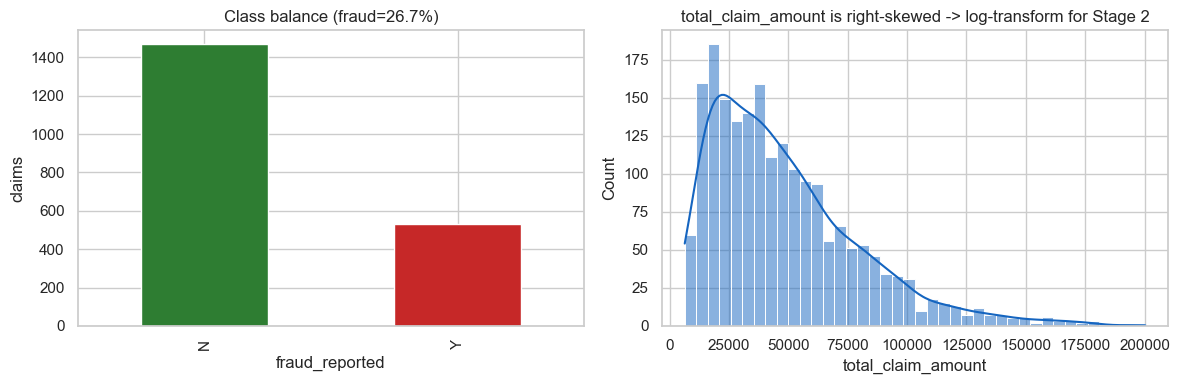

In [4]:
fraud_rate = (df.fraud_reported == 'Y').mean()
print(f'Fraud rate: {fraud_rate:.1%}')
print(f'"Always genuine" accuracy: {1-fraud_rate:.1%}  <-- catches 0 fraud!')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.fraud_reported.value_counts().plot.bar(ax=ax[0], color=['#2e7d32','#c62828'])
ax[0].set_title(f'Class balance (fraud={fraud_rate:.1%})'); ax[0].set_ylabel('claims')
sns.histplot(df.total_claim_amount, bins=40, kde=True, ax=ax[1], color='#1565c0')
ax[1].set_title('total_claim_amount is right-skewed -> log-transform for Stage 2')
plt.tight_layout(); plt.show()

## 3 · Train/test split (stratified)
Random **stratified** split (not time-based): claims are scored independently as they arrive — it's not a forecasting problem — and stratifying keeps the fraud rate identical in both folds.

In [5]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE,
                                     stratify=df.fraud_reported)
print('train:', train_df.shape, '| test:', test_df.shape)
print('fraud rate  train=%.1f%%  test=%.1f%%' % (
    (train_df.fraud_reported=='Y').mean()*100, (test_df.fraud_reported=='Y').mean()*100))

train: (1600, 40) | test: (400, 40)
fraud rate  train=26.6%  test=26.8%


## 4 · Stage 1 — Fraud classification
Each model is a **full `Pipeline`** (shared preprocessor + estimator), fit on train only. Using `build_preprocessor('fraud')` guarantees the notebook uses the *same* transforms as production. We compare a Logistic Regression baseline, Random Forest and XGBoost.

In [6]:
ycol = 'fraud_reported'
X_train, y_train = train_df.drop(columns=[ycol]), (train_df[ycol]=='Y').astype(int)
X_test,  y_test  = test_df.drop(columns=[ycol]),  (test_df[ycol]=='Y').astype(int)

candidates = {
    'logistic_regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'random_forest': RandomForestClassifier(n_estimators=300, max_depth=12,
                        min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
    'xgboost': XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                        subsample=0.9, colsample_bytree=0.9, eval_metric='aucpr',
                        random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist'),
}
rows, fitted = [], {}
for name, clf in candidates.items():
    pipe = Pipeline([('preprocess', build_preprocessor('fraud', cfg)), ('model', clf)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]; pred = (proba >= 0.5).astype(int)
    fitted[name] = (pipe, proba)
    rows.append({'model': name,
        'PR_AUC': average_precision_score(y_test, proba),
        'ROC_AUC': roc_auc_score(y_test, proba),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'accuracy': accuracy_score(y_test, pred)})
results = pd.DataFrame(rows).set_index('model').round(3)
results

[2026-06-29 23:24:29] INFO     src.feature_engineering:152 - Built 'fraud' preprocessor: 17 numeric + 16 categorical input columns


[2026-06-29 23:24:29] INFO     src.feature_engineering:152 - Built 'fraud' preprocessor: 17 numeric + 16 categorical input columns


[2026-06-29 23:24:30] INFO     src.feature_engineering:152 - Built 'fraud' preprocessor: 17 numeric + 16 categorical input columns


,PR_AUC,ROC_AUC,precision,recall,F1,accuracy
model,,,,,,
logistic_regression,0.625,0.805,0.675,0.505,0.578,0.802
random_forest,0.643,0.818,0.758,0.467,0.578,0.818
xgboost,0.627,0.798,0.646,0.495,0.561,0.792


Notice how **accuracy barely separates the models** while PR-AUC does — exactly why accuracy is misleading here. We pick the best model by PR-AUC.

Best fraud model: random_forest


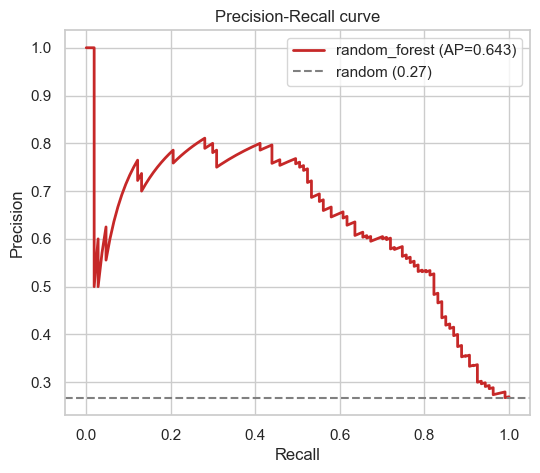

In [7]:
best_name = results['PR_AUC'].idxmax()
best_pipe, best_proba = fitted[best_name]
print('Best fraud model:', best_name)

prec, rec, _ = precision_recall_curve(y_test, best_proba)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, color='#c62828', lw=2,
         label=f'{best_name} (AP={average_precision_score(y_test, best_proba):.3f})')
plt.axhline(y_test.mean(), ls='--', color='gray', label=f'random ({y_test.mean():.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall curve')
plt.legend(); plt.show()

## 5 · Cost-sensitive threshold (move off 0.5)
0.5 implicitly assumes a false positive and a false negative cost the same. They don't: a **missed fraud** (FN) costs the payout; a **false alarm** (FP) costs an investigation. We sweep thresholds and pick the one that minimises total expected cost.

Cost-optimal threshold = 0.26  (vs default 0.50)
cost @ 0.26 = 970,000   |   cost @ 0.50 = 1,790,000


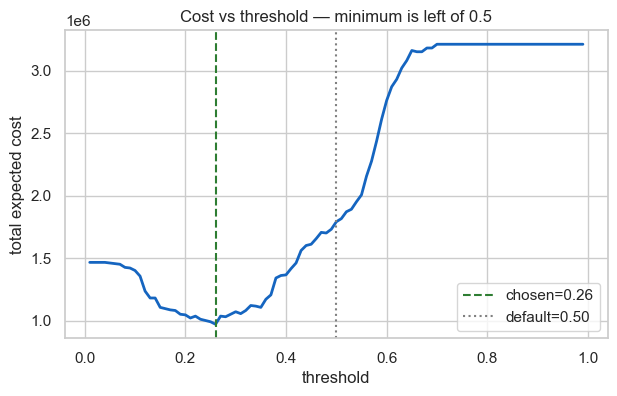

In [8]:
COST_FN = cfg.get('threshold.cost_false_negative')   # missed fraud (e.g. 30000)
COST_FP = cfg.get('threshold.cost_false_positive')   # false alarm (e.g. 5000)
grid = np.linspace(0.01, 0.99, 99)
def total_cost(t):
    pred = (best_proba >= t).astype(int)
    fn = ((y_test==1) & (pred==0)).sum(); fp = ((y_test==0) & (pred==1)).sum()
    return fn*COST_FN + fp*COST_FP
costs = np.array([total_cost(t) for t in grid])
best_t = grid[costs.argmin()]
print(f'Cost-optimal threshold = {best_t:.2f}  (vs default 0.50)')
print(f'cost @ {best_t:.2f} = {costs.min():,.0f}   |   cost @ 0.50 = {total_cost(0.5):,.0f}')

plt.figure(figsize=(7,4))
plt.plot(grid, costs, color='#1565c0', lw=2)
plt.axvline(best_t, color='#2e7d32', ls='--', label=f'chosen={best_t:.2f}')
plt.axvline(0.5, color='gray', ls=':', label='default=0.50')
plt.xlabel('threshold'); plt.ylabel('total expected cost'); plt.legend()
plt.title('Cost vs threshold — minimum is left of 0.5'); plt.show()

## 6 · Data leakage + Stage 2 severity
**Two leakage guards:**

1. **Exclude fraud claims from severity training** — fraudulent amounts are fabricated and would poison the reserving model. We also only predict severity for genuine claims in production, so train/serve populations must match.
2. **Drop the claim-component columns** — they sum to the target. `build_preprocessor('severity')` already excludes them.

We train on the **log-transformed** target and invert predictions back to rupees.

In [9]:
scol = 'total_claim_amount'
# leakage guard #1: genuine claims only
g_train = train_df[train_df.fraud_reported != 'Y']
g_test  = test_df[test_df.fraud_reported != 'Y']
print(f'Severity training rows: {len(g_train)} (dropped {len(train_df)-len(g_train)} fraud claims)')

Xs_tr, ys_tr = g_train.drop(columns=[scol, 'fraud_reported']), g_train[scol].astype(float)
Xs_te, ys_te = g_test.drop(columns=[scol, 'fraud_reported']),  g_test[scol].astype(float)

reg = TransformedTargetRegressor(  # log1p target, expm1 on predict
    regressor=RandomForestRegressor(n_estimators=300, max_depth=14, min_samples_leaf=5,
                                    random_state=RANDOM_STATE, n_jobs=-1),
    func=np.log1p, inverse_func=np.expm1)
sev_pipe = Pipeline([('preprocess', build_preprocessor('severity', cfg)), ('model', reg)])
sev_pipe.fit(Xs_tr, ys_tr)
sp = sev_pipe.predict(Xs_te)
print('RMSE = %.0f | MAE = %.0f | R2 = %.3f' % (
    np.sqrt(mean_squared_error(ys_te, sp)), mean_absolute_error(ys_te, sp), r2_score(ys_te, sp)))

Severity training rows: 1174 (dropped 426 fraud claims)
[2026-06-29 23:24:31] INFO     src.feature_engineering:152 - Built 'severity' preprocessor: 13 numeric + 16 categorical input columns


RMSE = 17889 | MAE = 12592 | R2 = 0.512


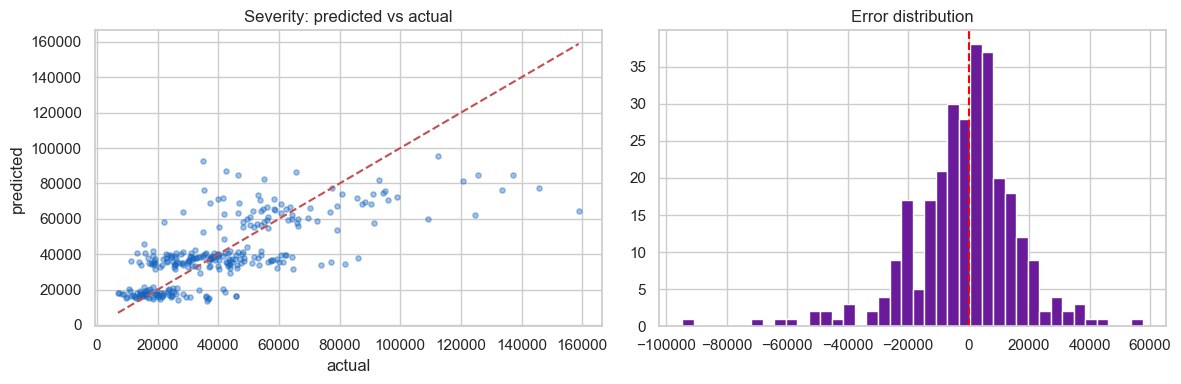

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(ys_te, sp, alpha=.4, s=14, color='#1565c0')
lo, hi = ys_te.min(), ys_te.max(); ax[0].plot([lo,hi],[lo,hi],'r--')
ax[0].set_xlabel('actual'); ax[0].set_ylabel('predicted'); ax[0].set_title('Severity: predicted vs actual')
ax[1].hist(sp - ys_te, bins=40, color='#6a1b9a'); ax[1].axvline(0, color='red', ls='--')
ax[1].set_title('Error distribution'); plt.tight_layout(); plt.show()

## 7 · Explainability with SHAP
Global feature importance for the fraud model — turning the black box into reasons a claims handler can act on. In the app these become plain-English factors per claim.

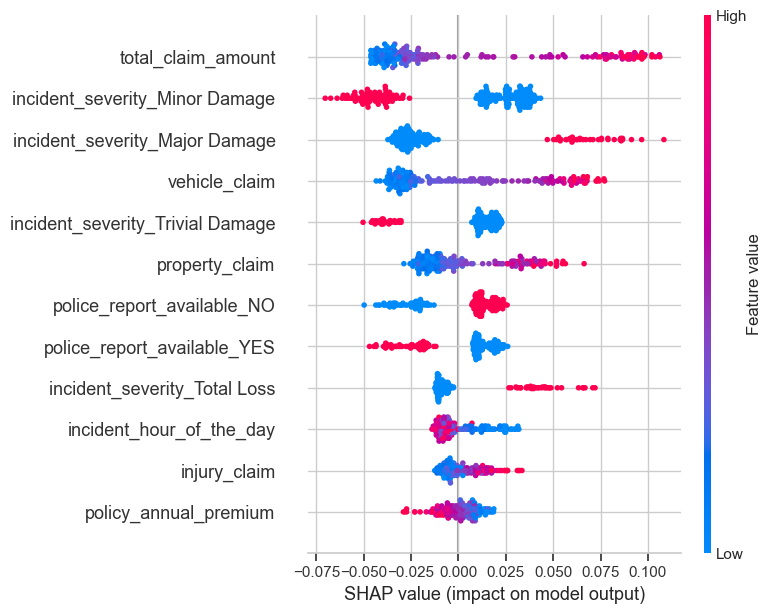

In [11]:
pre = best_pipe.named_steps['preprocess']
model = best_pipe.named_steps['model']
X_te_trans = pre.transform(X_test)
feat_names = get_feature_names(pre)
explainer = shap.TreeExplainer(model)
sv = explainer(X_te_trans[:200], check_additivity=False)
vals = sv.values[:, :, 1] if sv.values.ndim == 3 else sv.values
shap.summary_plot(vals, X_te_trans[:200], feature_names=feat_names, max_display=12, show=True)

## 8 · Chained inference — putting it together
A claim comes in → fraud check → if genuine, predict severity; if flagged, return `NEEDS REVIEW` with **no** severity. This is exactly what `src/inference_pipeline.py` does in production and what the Flask app serves.

In [12]:
def screen_claim(row: pd.DataFrame):
    p = float(best_pipe.predict_proba(row)[:, 1][0])
    if p >= best_t:
        return {'verdict': 'NEEDS_REVIEW', 'fraud_probability': round(p,3),
                'severity': None, 'note': 'flagged for manual review'}
    amount = float(sev_pipe.predict(row)[0])
    return {'verdict': 'GENUINE', 'fraud_probability': round(p,3),
            'predicted_severity': round(max(amount,0))}

# a clearly-genuine claim vs a clearly-suspicious one
genuine = test_df[test_df.fraud_reported=='N'].drop(columns=['fraud_reported']).iloc[[0]]
suspicious = test_df[test_df.fraud_reported=='Y'].drop(columns=['fraud_reported']).iloc[[0]]
print('Genuine    ->', screen_claim(genuine))
print('Suspicious ->', screen_claim(suspicious))

Genuine    -> {'verdict': 'NEEDS_REVIEW', 'fraud_probability': 0.343, 'severity': None, 'note': 'flagged for manual review'}
Suspicious -> {'verdict': 'NEEDS_REVIEW', 'fraud_probability': 0.588, 'severity': None, 'note': 'flagged for manual review'}


## ✅ Summary
We built a chained two-stage system: a **fraud classifier** (selected by PR-AUC, with a **cost-optimised threshold**) and a **severity regressor** (trained on genuine claims only, with two leakage guards and a log-transformed target), made explainable with **SHAP**.

**Next:** the production code is in `src/` (config-driven, logged, tested), served by `flask_app.py` (Flask), with MLflow tracking, drift monitoring, Docker and CI. See `BUILD_GUIDE.md` to build it all from scratch, and `reports/report.html` for the full write-up.